In [ ]:
import os
import subprocess

print("CUDA_PATH:", os.environ.get('CUDA_PATH', 'NOT SET'))
print("nvcc --version:")
subprocess.run(['nvcc', '--version'], check=True)

try:
    import cupy as cp
    print("CuPy GPU count:", cp.cuda.runtime.getDeviceCount())
    print("GPU name:", cp.cuda.runtime.getDeviceProperties(0)['name'])
except Exception as e:
    print("CuPy error:", e)

CUDA_PATH: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.2
nvcc --version:
CuPy GPU count: 1
GPU name: b'NVIDIA RTX A5500 Laptop GPU'


In [ ]:
import cudf
print(cudf.Series([1, 2, 3]))

ModuleNotFoundError: No module named 'cudf'

In [ ]:
from cuml.experimental import accel
accel.patch_sklearn()
try:
    from cuml.experimental import accel
    accel.patch_sklearn()
    print("✅ cuML NVIDIA GPU acceleration active")
except ImportError:
    print("⚠️  cuML not available, using CPU")

ModuleNotFoundError: No module named 'cuml'

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cupy as cp

from sklearnex import patch_sklearn
patch_sklearn()

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Optional Intel offload context; harmless if unsupported in your setup
try:
    from sklearnex import config_context
    HAS_CONFIG_CONTEXT = True
except Exception:
    HAS_CONFIG_CONTEXT = False

warnings.filterwarnings("ignore")

csv_path = r"..\Data\SyntheticData\2026_03_31_01_52_14\std_synthetic_data_2026_03_31_01_52_14.csv"  # change if needed
df = pd.read_csv(csv_path)

# =========================
# 2. Build features / target
# =========================
target = "Problem_SKU"

# one-hot encode Storage_Size
size_dummies = pd.get_dummies(df["Storage_Size"], prefix="Size", drop_first=True)

# binary encode
defect_linked_num = df["Defect_In_Linked_Receive"].astype(int)

numeric_features = [
    "Global_SKU_Defect_Rate_%_std",
    "ABS_Volume_Difference_std",
    "Aisle_Hold_%_std",
    "#_Pick_Events_std",
    "#_Pick_Events_In_Clique_std",
    "#_Picks_std",
    "#_Picks_In_Clique_std",
    "Time_In_Loc_std",
    "Current_Max_Volume_std",
]



X_cpu = pd.concat([df[numeric_features], size_dummies, defect_linked_num], axis=1)
y = df[target].astype(int)

#X_gpu = cp.asarray(X_cpu.values)

# =========================
# 3. Train/test split
# =========================
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, random_state=42, stratify=y
#)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cpu)

# =========================
# 3. Scoring helper
# =========================
def score_clustering(X_mat, labels):
    labels = np.asarray(labels)
    mask = labels != -1
    unique_clusters = np.unique(labels[mask])

    if len(unique_clusters) < 2:
        return {
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan,
            "n_clusters": len(unique_clusters),
            "noise_rate": float((labels == -1).mean())
        }

    X_use = X_mat[mask]
    y_use = labels[mask]

    return {
        "silhouette": silhouette_score(X_use, y_use),
        "calinski_harabasz": calinski_harabasz_score(X_use, y_use),
        "davies_bouldin": davies_bouldin_score(X_use, y_use),
        "n_clusters": len(unique_clusters),
        "noise_rate": float((labels == -1).mean())
    }

def fit_predict_with_optional_gpu(model, X_data):
    start = time.time()

    if HAS_CONFIG_CONTEXT:
        try:
            with config_context(target_offload="gpu:1"):
                print("Attempting GPU acceleration...")
                labels = model.fit_predict(X_data)
            elapsed = time.time() - start
            return labels, elapsed, "gpu_attempted"
        except Exception:
            print("GPU acceleration failed, falling back to CPU...")
            labels = model.fit_predict(X_data)
            elapsed = time.time() - start
            return labels, elapsed, "cpu_fallback"
    else:
        labels = model.fit_predict(X_data)
        elapsed = time.time() - start
        return labels, elapsed, "cpu_only"

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


# DB Scan

In [3]:
# =========================
# 5. DBSCAN
# =========================
dbscan_results = []
best_dbscan = None
best_dbscan_score = -np.inf

for eps in np.arange(0.3, 2.1, 0.2):
    for min_samples in [3, 5, 8, 10]:
        model = DBSCAN(eps=float(eps), min_samples=min_samples)
        labels, elapsed, mode = fit_predict_with_optional_gpu(model, X_cpu)
        scores = score_clustering(X_cpu, labels)

        row = {
            "algorithm": "DBSCAN",
            "param_name": "eps/min_samples",
            "param_value": f"{eps:.1f}/{min_samples}",
            "fit_mode": mode,
            "fit_seconds": elapsed,
            **scores
        }
        dbscan_results.append(row)

        sil_disp = scores["silhouette"]
        sil_txt = f"{sil_disp:.4f}" if not np.isnan(sil_disp) else "nan"
        print(
            f"DBSCAN eps={eps:.1f}, min_samples={min_samples:<2} | "
            f"mode={mode:<12} | sil={sil_txt} | "
            f"clusters={scores['n_clusters']} | time={elapsed:.2f}s"
        )

        if scores["n_clusters"] >= 2 and not np.isnan(scores["silhouette"]):
            if scores["silhouette"] > best_dbscan_score:
                best_dbscan_score = scores["silhouette"]
                best_dbscan = (eps, min_samples, labels, scores)

Attempting GPU acceleration...
GPU acceleration failed, falling back to CPU...
DBSCAN eps=0.3, min_samples=3  | mode=cpu_fallback | sil=nan | clusters=1 | time=9.16s
Attempting GPU acceleration...
GPU acceleration failed, falling back to CPU...
DBSCAN eps=0.3, min_samples=5  | mode=cpu_fallback | sil=nan | clusters=0 | time=9.24s
Attempting GPU acceleration...
GPU acceleration failed, falling back to CPU...
DBSCAN eps=0.3, min_samples=8  | mode=cpu_fallback | sil=nan | clusters=0 | time=9.37s
Attempting GPU acceleration...
GPU acceleration failed, falling back to CPU...
DBSCAN eps=0.3, min_samples=10 | mode=cpu_fallback | sil=nan | clusters=0 | time=9.86s
Attempting GPU acceleration...
GPU acceleration failed, falling back to CPU...
DBSCAN eps=0.5, min_samples=3  | mode=cpu_fallback | sil=0.3474 | clusters=994 | time=9.90s
Attempting GPU acceleration...
GPU acceleration failed, falling back to CPU...
DBSCAN eps=0.5, min_samples=5  | mode=cpu_fallback | sil=0.4257 | clusters=30 | time=2

# GMM Clustering

In [4]:
# =========================
# 6. GMM
# =========================
# GMM support may fall back depending on backend support and parameters.
gmm_results = []
best_gmm = None
best_gmm_score = -np.inf

for k in range(2, 11):
    model = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42
    )

    start = time.time()
    try:
        if HAS_CONFIG_CONTEXT:
            with config_context(target_offload="gpu:1"):
                labels = model.fit_predict(X_cpu)
            mode = "gpu_attempted"
        else:
            labels = model.fit_predict(X_cpu)
            mode = "cpu_only"
    except Exception:
        labels = model.fit_predict(X_cpu)
        mode = "cpu_fallback"

    elapsed = time.time() - start
    scores = score_clustering(X_cpu, labels)

    row = {
        "algorithm": "GMM",
        "param_name": "n_components",
        "param_value": k,
        "fit_mode": mode,
        "fit_seconds": elapsed,
        **scores
    }
    gmm_results.append(row)

    print(
        f"GMM k={k:<2} | mode={mode:<12} | "
        f"sil={scores['silhouette']:.4f} | time={elapsed:.2f}s"
    )

    if not np.isnan(scores["silhouette"]) and scores["silhouette"] > best_gmm_score:
        best_gmm_score = scores["silhouette"]
        best_gmm = (k, labels, scores)

GMM k=2  | mode=cpu_fallback | sil=0.1600 | time=4.52s
GMM k=3  | mode=cpu_fallback | sil=0.0672 | time=6.66s
GMM k=4  | mode=cpu_fallback | sil=0.0440 | time=10.42s
GMM k=5  | mode=cpu_fallback | sil=0.0299 | time=13.81s
GMM k=6  | mode=cpu_fallback | sil=0.0450 | time=14.42s
GMM k=7  | mode=cpu_fallback | sil=0.0064 | time=13.71s
GMM k=8  | mode=cpu_fallback | sil=-0.0169 | time=28.99s
GMM k=9  | mode=cpu_fallback | sil=-0.0204 | time=21.66s
GMM k=10 | mode=cpu_fallback | sil=0.0008 | time=47.65s


# Heirarchical Clustering

In [ ]:
# =========================
# 7. Hierarchical
# =========================
# AgglomerativeClustering is generally CPU here.
hier_results = []
best_hier = None
best_hier_score = -np.inf

for k in range(2, 11):
    for linkage in ["ward", "complete", "average"]:
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        #unable to run because of memory constraints
        start = time.time()
        labels = model.fit_predict(X_cpu)
        elapsed = time.time() - start

        scores = score_clustering(X_cpu, labels)

        row = {
            "algorithm": "Hierarchical",
            "param_name": "n_clusters/linkage",
            "param_value": f"{k}/{linkage}",
            "fit_mode": "cpu_only",
            "fit_seconds": elapsed,
            **scores
        }
        hier_results.append(row)

        print(
            f"Hierarchical k={k:<2}, linkage={linkage:<8} | "
            f"sil={scores['silhouette']:.4f} | time={elapsed:.2f}s"
        )

        if not np.isnan(scores["silhouette"]) and scores["silhouette"] > best_hier_score:
            best_hier_score = scores["silhouette"]
            best_hier = (k, linkage, labels, scores)

MemoryError: Unable to allocate 282. GiB for an array with shape (37812362500,) and data type float64

# KNN Means

In [7]:
# =========================
# 4. KMeans
# =========================
kmeans_results = []
best_kmeans = None
best_kmeans_score = -np.inf

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels, elapsed, mode = fit_predict_with_optional_gpu(model, X_cpu)
    scores = score_clustering(X_cpu, labels)

    row = {
        "algorithm": "KMeans",
        "param_name": "n_clusters",
        "param_value": k,
        "fit_mode": mode,
        "fit_seconds": elapsed,
        **scores
    }
    kmeans_results.append(row)

    print(
        f"KMeans k={k:<2} | mode={mode:<12} | "
        f"sil={scores['silhouette']:.4f} | time={elapsed:.2f}s"
    )

    if not np.isnan(scores["silhouette"]) and scores["silhouette"] > best_kmeans_score:
        best_kmeans_score = scores["silhouette"]
        best_kmeans = (k, labels, scores)

Attempting GPU acceleration...
GPU acceleration failed, falling back to CPU...


KeyboardInterrupt: 

# Plots and Graphs


Top rows:
  algorithm       param_name param_value      fit_mode  fit_seconds  \
0    DBSCAN  eps/min_samples       0.3/3  cpu_fallback     9.160935   
1    DBSCAN  eps/min_samples       0.3/5  cpu_fallback     9.243364   
2    DBSCAN  eps/min_samples       0.3/8  cpu_fallback     9.366458   
3    DBSCAN  eps/min_samples      0.3/10  cpu_fallback     9.864161   
4    DBSCAN  eps/min_samples       0.5/3  cpu_fallback     9.898547   

   silhouette  calinski_harabasz  davies_bouldin  n_clusters  noise_rate  
0         NaN                NaN             NaN           1    0.999989  
1         NaN                NaN             NaN           0    1.000000  
2         NaN                NaN             NaN           0    1.000000  
3         NaN                NaN             NaN           0    1.000000  
4     0.34739          52.074435        0.859349         994    0.986516  

Best models:
   algorithm param_value      fit_mode  silhouette  calinski_harabasz  \
5     DBSCAN       0.5/5 

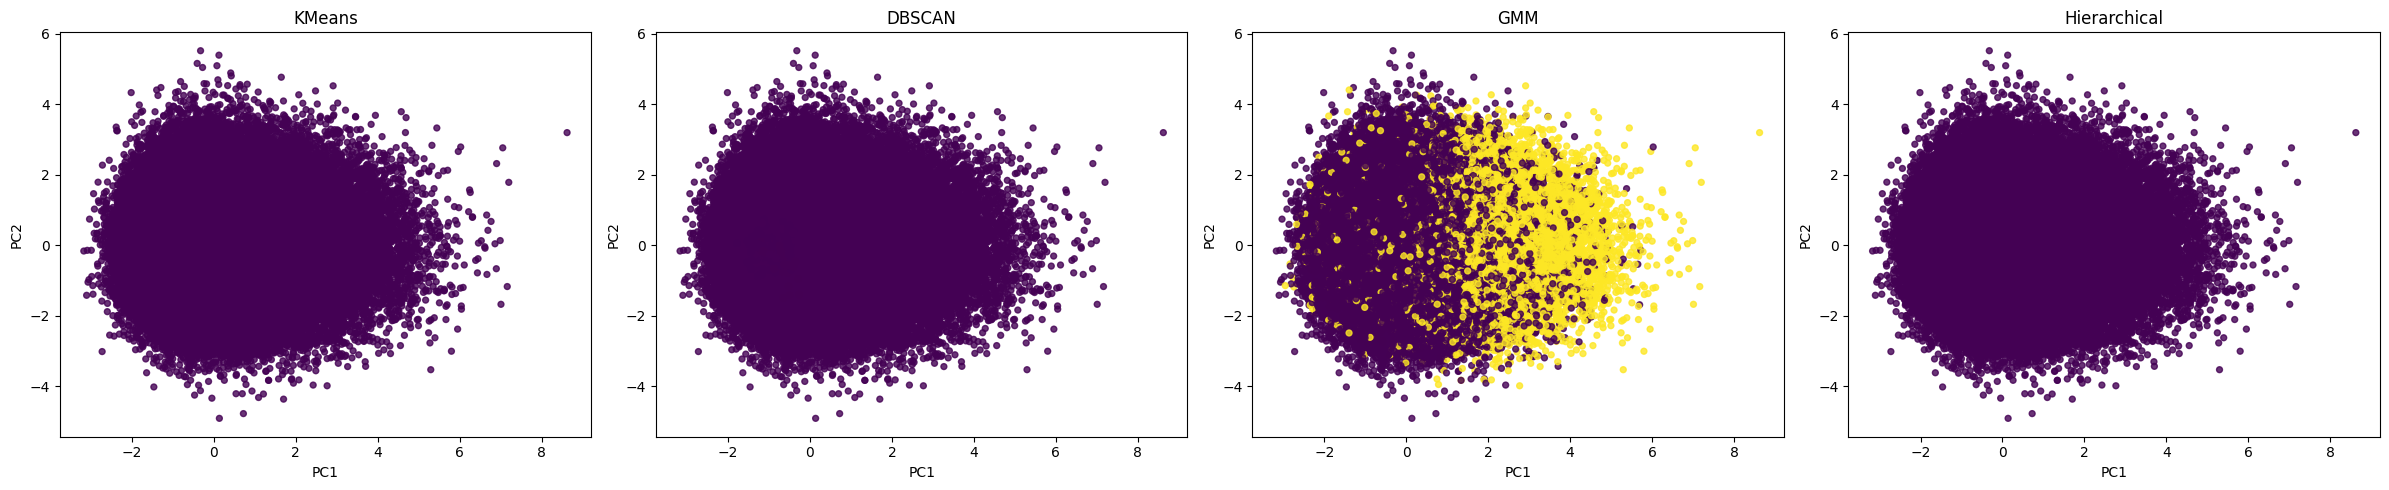

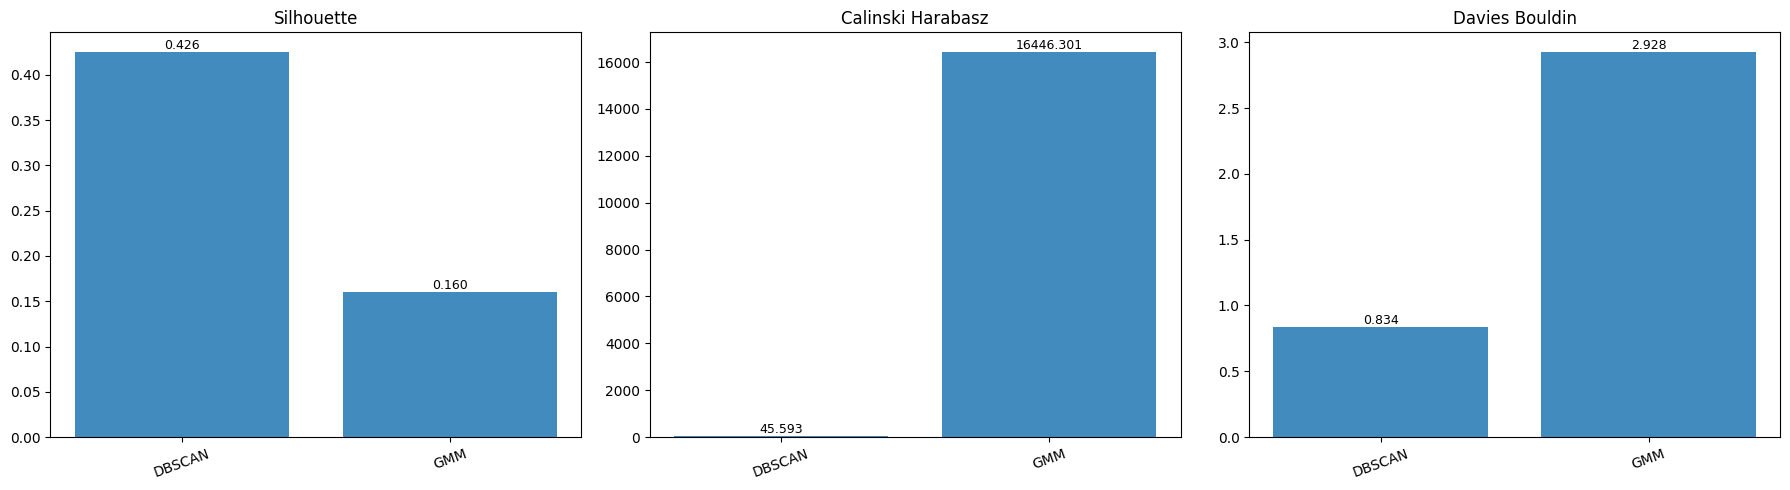


Saved: output_gpu_clustering\clustering_metrics_all.csv
Saved: output_gpu_clustering\clustering_best_models.csv
Saved: output_gpu_clustering\clustering_pca_comparison.png


NameError: name 'kmeans_plot_path' is not defined

In [10]:
# =========================
# 8. Combine results
# =========================
metrics_df = pd.concat([
    pd.DataFrame(kmeans_results),
    pd.DataFrame(dbscan_results),
    pd.DataFrame(gmm_results),
    pd.DataFrame(hier_results)
], ignore_index=True)

print("\nTop rows:")
print(metrics_df.head())

# =========================
# 9. Save metrics
# =========================
out_dir = "output_gpu_clustering"
os.makedirs(out_dir, exist_ok=True)

metrics_csv = os.path.join(out_dir, "clustering_metrics_all.csv")
metrics_df.to_csv(metrics_csv, index=False)

# =========================
# 10. Best-per-algorithm table
# =========================
best_rows = []
for algo in metrics_df["algorithm"].unique():
    sub = metrics_df[metrics_df["algorithm"] == algo].dropna(subset=["silhouette"]).copy()
    if len(sub) > 0:
        best_rows.append(sub.loc[sub["silhouette"].idxmax()])

best_df = pd.DataFrame(best_rows)
best_csv = os.path.join(out_dir, "clustering_best_models.csv")
best_df.to_csv(best_csv, index=False)

print("\nBest models:")
print(best_df[[
    "algorithm", "param_value", "fit_mode",
    "silhouette", "calinski_harabasz", "davies_bouldin", "fit_seconds"
]])

# =========================
# 11. PCA cluster plots
# =========================
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

plot_labels = {
    "KMeans": best_kmeans[1] if best_kmeans else np.zeros(len(X_cpu), dtype=int),
    "DBSCAN": best_dbscan[2] if best_dbscan else np.full(len(X_cpu), -1),
    "GMM": best_gmm[1] if best_gmm else np.zeros(len(X_cpu), dtype=int),
    "Hierarchical": best_hier[2] if best_hier else np.zeros(len(X_cpu), dtype=int),
}

for ax, (name, labels) in zip(axes, plot_labels.items()):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", s=18, alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
cluster_plot_path = os.path.join(out_dir, "clustering_pca_comparison.png")
plt.savefig(cluster_plot_path, dpi=200, bbox_inches="tight")
plt.show()



# =========================
# 13. Best metrics comparison
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(
    axes,
    ["silhouette", "calinski_harabasz", "davies_bouldin"]
):
    bars = ax.bar(best_df["algorithm"], best_df[metric], alpha=0.85)
    ax.set_title(metric.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=20)

    for bar, val in zip(bars, best_df[metric]):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

plt.tight_layout()
metrics_plot_path = os.path.join(out_dir, "clustering_best_metrics.png")
plt.savefig(metrics_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"\nSaved: {metrics_csv}")
print(f"Saved: {best_csv}")
print(f"Saved: {cluster_plot_path}")
print(f"Saved: {kmeans_plot_path}")
print(f"Saved: {metrics_plot_path}")